In [1]:
# Visualize the species data from EPSG:32632 to WGS84 centered at specific coordinates
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer
from rasterio.windows import Window
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

# Interpolate GEDI AGBD data to 10m pixels
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from datetime import datetime

import sys
sys.path.append('script')
from utils import GEDIdata


In [148]:
sys.modules.pop('utils', None)

<module 'utils' from '/Volumes/siyux1927/thesis/script/utils.py'>

## Content
1. [GEDI Interpolation](#GEDI-Interpolation)
2. [Dominant Tree Species for Germany (2017/2018))](#Dominant-Tree-Species-for-Germany-(2017/2018))
3. [Forest biomass map of EU27 for 2020](#Forest-biomass-map-of-EU27-for-2020)

## GEDI Interpolation
[source](https://search.earthdata.nasa.gov/search?projectId=8383405426&portal=ornldaac) 

### load GEDI data

unique data points: (32734, 4)
valid data points: (14408, 5)
====== GEDI data: agbd ======
total data points: (14408, 5)
min: 20.991622924804688, max: 1113.7032470703125
example:
         lat       lon        feat      beam  id
0  49.329705  7.894361  169.381226  BEAM0000   0
1  49.329536  7.895101  175.742905  BEAM0000   1
2  49.329367  7.895842   92.944107  BEAM0000   2
3  49.329198  7.896585  145.668884  BEAM0000   3
4  49.329029  7.897328   70.362846  BEAM0000   4
<urlopen error [Errno 54] Connection reset by peer><urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>

<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>


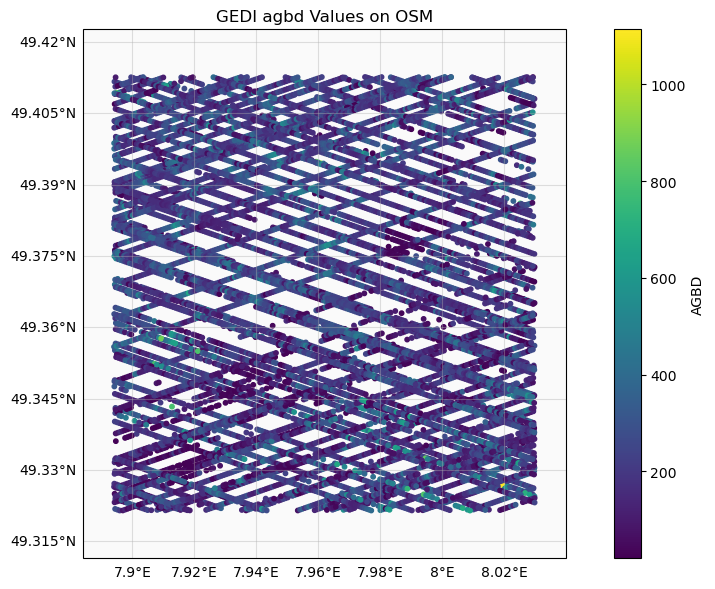

In [2]:
# try to combine data from multiple years for better interpolation
GEDI_PATH = 'data/gedi/gedi_species_sample_1920212224'
gedi_agbd = GEDIdata('agbd', GEDI_PATH)
gedi_agbd.visualize_gedi_osm(0.01,10,12)

unique data points: (32734, 4)
valid data points: (14408, 5)
====== GEDI data: Canopy Height ======
total data points: (14408, 5)
min: 10.068763732910156, max: 13.44879150390625
example:
         lat       lon       feat      beam  id
0  49.329705  7.894361  11.147646  BEAM0000   0
1  49.329536  7.895101  11.134182  BEAM0000   1
2  49.329367  7.895842  10.923369  BEAM0000   2
3  49.329198  7.896585  11.066616  BEAM0000   3
4  49.329029  7.897328  10.705139  BEAM0000   4
<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer><urlopen error [Errno 54] Connection reset by peer>

<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>
<urlopen error [Errno 54] Connection reset by peer>


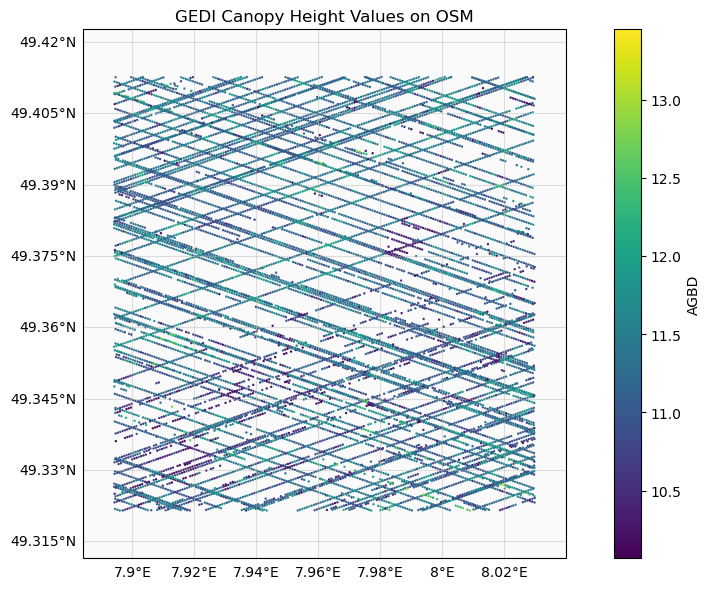

In [3]:
# load gedi canopy height data
gedi_ch = GEDIdata('xvar', GEDI_PATH)
gedi_ch.visualize_gedi_osm(0.01,0.5,12)

### Interpolation

In [4]:
def interpolate_missing(arr):
    """
    Interpolate missing (NaN) values in a 2D NumPy array using linear interpolation.
    For points that cannot be interpolated linearly, use nearest-neighbor interpolation.
    
    Parameters:
        arr (np.ndarray): 2D numpy array containing NaNs.
        
    Returns:
        np.ndarray: Array of the same shape with interpolated values.
    """
    # Get the number of rows and columns
    nrows, ncols = arr.shape
    # Create a mesh grid corresponding to the array indices.
    grid_x, grid_y = np.meshgrid(np.arange(ncols), np.arange(nrows))
    # Create a mask for the valid (non-NaN) entries.
    valid_mask = ~np.isnan(arr)
    
    # Get the coordinates and values of valid points.
    points = np.column_stack((grid_x[valid_mask], grid_y[valid_mask]))
    values = arr[valid_mask]
    # Flatten the grid coordinates for interpolation.
    grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))
    
    # Perform linear interpolation.
    interpolated = griddata(points, values, grid_points, method='linear')
    
    # In case some points are still NaN (e.g., outside the convex hull),
    # fill them in using nearest-neighbor interpolation.
    nan_mask = np.isnan(interpolated)
    if np.any(nan_mask):
        interpolated[nan_mask] = griddata(points, values, grid_points[nan_mask], method='nearest')
    
    # Reshape the result back to the original array shape.
    return interpolated.reshape(arr.shape)

In [5]:
def gedi_interpolate_preprocess(pixel_size=100):
    # Get data from gedi_agbd
    lats = gedi_agbd.df_valid['lat'].values
    lons = gedi_agbd.df_valid['lon'].values
    agbd_values = gedi_agbd.df_valid['feat'].values

    # Calculate mean lat/lon for accurate pixel size conversion
    mean_lat = np.mean(lats)

    # Define the grid for 10m x 10m pixels
    # Convert lat/lon to approximate 10m grid
    lat_res = pixel_size / 111000  # 10m in degrees latitude
    lon_res = pixel_size / (111000 * np.cos(np.radians(mean_lat)))  # 10m in degrees longitude

    # Calculate grid boundaries with a small buffer
    lat_min, lat_max = np.min(lats) - lat_res, np.max(lats) + lat_res
    lon_min, lon_max = np.min(lons) - lon_res, np.max(lons) + lon_res
    grid = [lat_min, lat_max, lon_min, lon_max]

    # Create grid edges
    lat_edges = np.arange(lat_min, lat_max + lat_res, lat_res)
    lon_edges = np.arange(lon_min, lon_max + lon_res, lon_res)

    # Create a 2D grid for the interpolation
    grid_lat, grid_lon = np.meshgrid(lat_edges, lon_edges, indexing='ij')

    # Create an empty array to hold the binned data
    grid_shape = (len(lat_edges), len(lon_edges))
    binned_data = np.full(grid_shape, np.nan)

    # Bin the data points into the grid
    for i in range(len(lats)):
        lat_idx = np.searchsorted(lat_edges, lats[i]) - 1
        lon_idx = np.searchsorted(lon_edges, lons[i]) - 1
        
        if 0 <= lat_idx < grid_shape[0] and 0 <= lon_idx < grid_shape[1]:
            # If there's already a value, average them
            if np.isnan(binned_data[lat_idx, lon_idx]):
                binned_data[lat_idx, lon_idx] = agbd_values[i]
            else:
                binned_data[lat_idx, lon_idx] = (binned_data[lat_idx, lon_idx] + agbd_values[i]) / 2
    return binned_data, grid

In [6]:
def gedi_interpolate(pixel_size=100):
    binned_data, grid = gedi_interpolate_preprocess(pixel_size)

    # Interpolate missing values
    start_time = datetime.now()
    interpolated_data = interpolate_missing(binned_data)
    end_time = datetime.now()
    elapsed_time = end_time - start_time
    print(f"Time for interpolating missing values: {elapsed_time}")

    print(f"- Interpolated grid dimensions: {interpolated_data.shape}")
    print(f"- Resolution: {pixel_size}m x {pixel_size}m")
    print(f"- Valid data points: {np.sum(~np.isnan(interpolated_data))}")
    print(f"- Coverage area: ~{np.sum(~np.isnan(interpolated_data)) * 0.0001:.2f} km²")
    print(f"min: {interpolated_data.min()}, max: {interpolated_data.max()}")
    print(f"Original data has {np.isnan(binned_data).sum()} NaNs")
    print(f"Interpolated data has {np.isnan(interpolated_data).sum()} NaNs")
    return interpolated_data, grid

def gedi_interpolate_visualize(interpolated_data, grid, pixel_size, year):
    lat_min, lat_max, lon_min, lon_max = grid
    # Create a figure to visualize the interpolated data
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the interpolated data
    cmap = plt.cm.viridis
    im = ax.imshow(interpolated_data, cmap=cmap, 
                extent=[lon_min, lon_max, lat_min, lat_max], 
                origin='lower', aspect='auto')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('AGBD (Mg/ha)')

    # Add labels and title
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'GEDI AGBD Interpolated to {pixel_size}m Resolution, year: {year}')

    plt.tight_layout()
    plt.show()


Time for interpolating missing values: 0:00:01.600220
- Interpolated grid dimensions: (1015, 985)
- Resolution: 10m x 10m
- Valid data points: 999775
- Coverage area: ~99.98 km²
min: 20.991622924804688, max: 1113.7032470703125
Original data has 985430 NaNs
Interpolated data has 0 NaNs


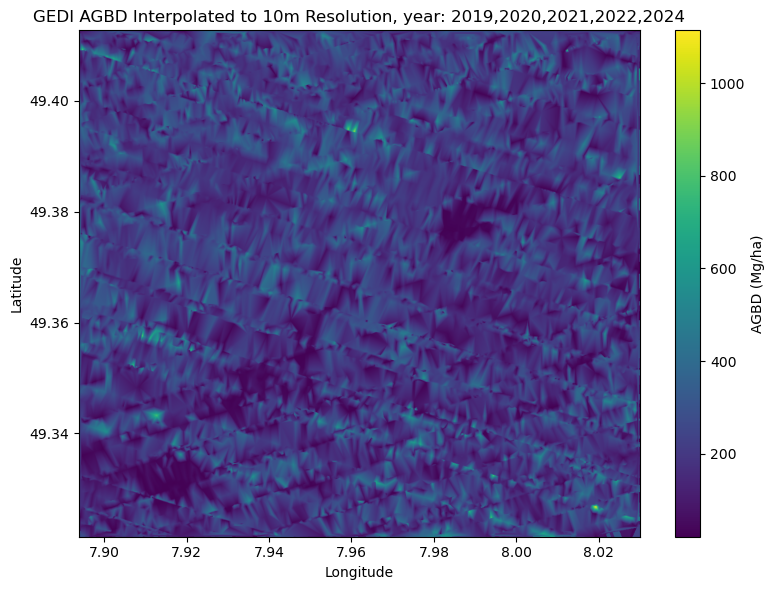

In [10]:
year = "2019,2020,2021,2022,2024"
pixel_size = 10
interpolated_agbd, grid = gedi_interpolate(pixel_size)
gedi_interpolate_visualize(interpolated_agbd, grid, pixel_size, year)

## Dominant Tree Species for Germany (2017/2018)
❌❌❌ not able for use \
[map](https://atlas.thuenen.de/catalogue/#/dataset/100) \
[data access](https://www.openagrar.de/receive/openagrar_mods_00084346)

In [2]:
SPECIES_PATH = 'data/species/Dominant_Species_Class.tif'
with rasterio.open(SPECIES_PATH) as src:
    print("metadata of dominant species class:")

    print(f"- data type: {src.dtypes[0]}")
    print(f"- CRS: {src.crs}")
    print(f"- bounds: {src.bounds}")
    print(f"    - width: {src.width}")
    print(f"    - height: {src.height}")
    print(f"- resolution: {src.res} in meters")
    print(f"- nodata: {src.nodata}")
    band = src.read(1)


metadata of dominant species class:
- data type: uint8
- CRS: EPSG:32632
- bounds: BoundingBox(left=280460.0, bottom=5236910.0, right=921220.0, top=6098380.0)
    - width: 64076
    - height: 86147
- resolution: (10.0, 10.0) in meters
- nodata: 255.0


In [3]:
display(pd.read_csv('data/species/tree_species_code.csv').T)


,0,1,2,3,4,5,6,7,8,9,10
ID,2,3,4,5,6,8,9,10,14,16,17
species,Birch,Beech,Douglas fir,Oak,Alder,Spruce,Pine,Larch,Fir,ODH,ODL


### distribution of the species

In [4]:
# Define species mapping
SPECIES_MAPPING = {
    2: 'Birch',
    3: 'Beech',
    4: 'Douglas fir',
    5: 'Oak',
    6: 'Alder',
    8: 'Spruce',
    9: 'Pine',
    10: 'Larch',
    14: 'Fir',
    16: 'ODH', # Other deciduous - high life expectancy
    17: 'ODL' # Other deciduous - low life expectancy
}
CLASS_NUM = 11

colors = plt.cm.tab20(np.linspace(0, 1, CLASS_NUM))
cmap = ListedColormap(colors)

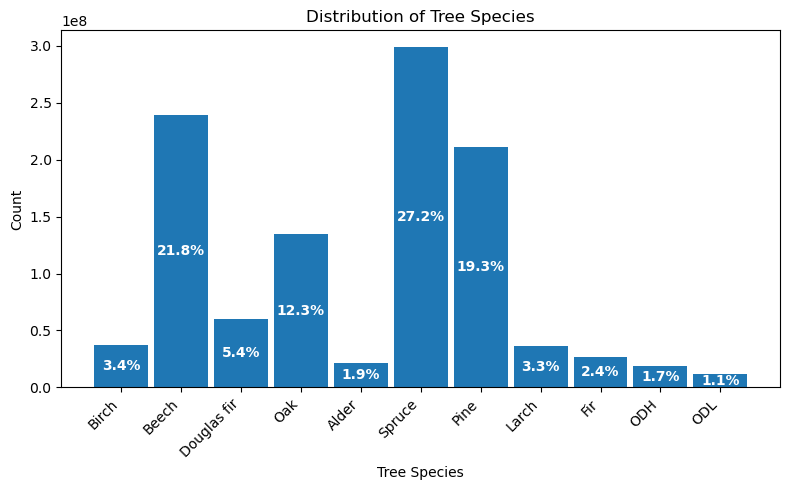

,Code,Species,Count,Percentage
0,2,Birch,37634479,3.43%
1,3,Beech,239360028,21.83%
2,4,Douglas fir,59745466,5.45%
3,5,Oak,134375612,12.26%
4,6,Alder,21326608,1.95%
5,8,Spruce,298638669,27.24%
6,9,Pine,211543643,19.30%
7,10,Larch,36698225,3.35%
8,14,Fir,26364113,2.40%
9,16,ODH,18984680,1.73%


In [5]:
def species_distribution(band):
    unique_values, counts = np.unique(band[band != 255], return_counts=True)
    species_labels = [SPECIES_MAPPING.get(val) for val in unique_values]
    total = sum(counts)
    species_data = {
        'Code': unique_values,
        'Species': species_labels,
        'Count': counts,
        'Percentage': [f'{count/total:.2%}' for count in counts]
    }
    species_df = pd.DataFrame(species_data)
    species_df = species_df.sort_values('Code', ascending=True)

    species_histogram(counts, species_labels, total)
    return species_df

def species_histogram(counts, species_labels, total):
    # Create a histogram with no gaps between bars
    plt.figure(figsize=(8, 5))
    bars = plt.bar(range(len(species_labels)), counts, width=0.9)
    plt.xticks(range(len(species_labels)), species_labels, rotation=45, ha='right')

    # Add percentage labels on each bar
    for i, count in enumerate(counts):
        percentage_value = count/total * 100
        plt.text(i, count/2, f'{percentage_value:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold')

    plt.xlabel('Tree Species')
    plt.ylabel('Count')
    plt.title('Distribution of Tree Species')
    plt.tight_layout()
    plt.show()

species_df = species_distribution(band)
display(species_df)


### visualize a small region

In [6]:
def from_wgs84(lat, lon):
    transformer_reverse = Transformer.from_crs(4326, 32632, always_xy=True)
    x, y = transformer_reverse.transform(lon, lat)
    return x, y

def to_wgs84(x, y):
    transformer = Transformer.from_crs(32632, 4326, always_xy=True)
    lon, lat = transformer.transform(x, y)
    return lon, lat


left, bottom, right, top: 7.894041354606359, 49.32145771789836, 8.029859431055153, 49.41263004661555
[7.894041354606359, 8.029859431055153, 49.32145771789836, 49.41263004661555]


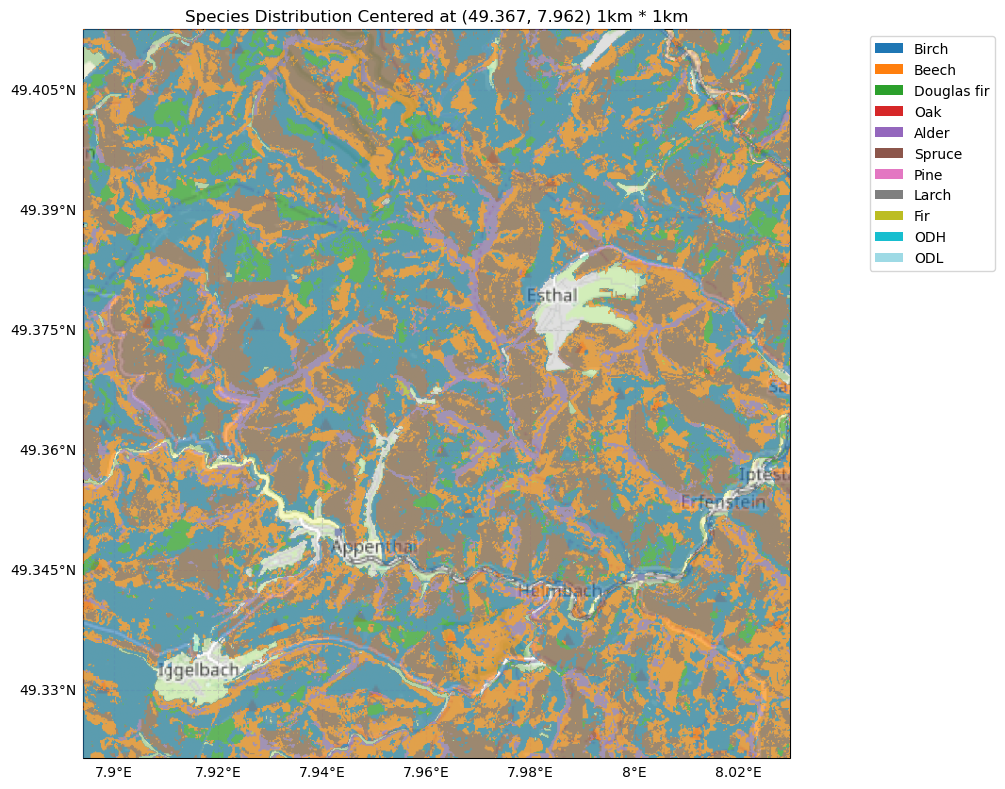

In [8]:
def visualize_species_data(input_tiff, center_lat, center_lon, window_size):  
    # Open the species raster file in EPSG:32632
    with rasterio.open(input_tiff) as src:
        # from coordinates get the pixel from the raster
        center_x, center_y = from_wgs84(center_lat, center_lon)
        row, col = src.index(center_x, center_y)
        # set window in pixels
        window = Window(col - window_size // 2, 
                        row - window_size // 2, 
                        window_size, 
                        window_size)
        # crop with window
        species_data = src.read(1, window=window)

        # get the coordinates of the window, as 32632
        left, bottom, right, top = src.window_bounds(window)
        # Transform the bounds to WGS84
        left, bottom = to_wgs84(left, bottom)
        right, top = to_wgs84(right, top)
        extent = [left, right, bottom, top]
        print(f"left, bottom, right, top: {left}, {bottom}, {right}, {top}")
        # Create figure and axis with OSM projection
        osm = cimgt.OSM()
        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=osm.crs)
        # Set map extent using transformed bounds
        # ax.set_extent([left-0.01, right+0.01, bottom-0.005, top+0.005])
        ax.set_extent([left, right, bottom, top])
        print(extent)
        # Add OSM tiles with low transparency
        ax.add_image(osm, 12, alpha=0.9)

        # Create a masked array to hide values 16 and 17
        masked_data = np.ma.masked_array(species_data, (species_data == 255))
        # Add species data as an overlay
        img = ax.imshow(masked_data, extent=extent, transform=ccrs.PlateCarree(), 
                       cmap=cmap, alpha=0.6, zorder=10)
        
        # Create custom legend
        legend_elements = []
        for i, val in enumerate(np.unique(masked_data.compressed())):
            if val in SPECIES_MAPPING:
                legend_elements.append(Patch(facecolor=cmap(i), label=SPECIES_MAPPING[val]))
        # Add the legend to the plot
        ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1))
        
        # Add title
        ax.set_title(f'Species Distribution Centered at ({center_lat}, {center_lon}) 1km * 1km')
        
        # Add longitude and latitude labels on axes
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}
        
        plt.tight_layout()
        plt.show()

visualize_species_data(SPECIES_PATH, 49.367, 7.962, 1000)


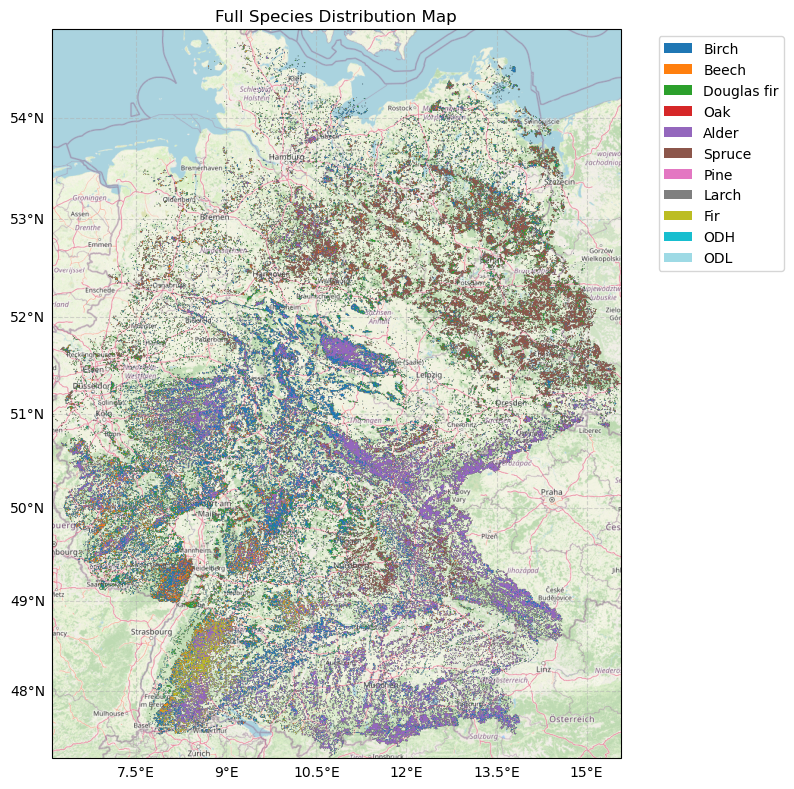

In [63]:
def visualize_species_data(input_tiff, center_lat=None, center_lon=None, window_size=None):  
    # Open the species raster file in EPSG:32632
    with rasterio.open(input_tiff) as src:
        # Read the entire raster at reduced resolution (every 4th pixel)
        species_data = src.read(1, out_shape=(src.height // 10, src.width // 10))

        # Get the bounds of the entire raster
        left, bottom, right, top = src.bounds
        # Transform the bounds to WGS84
        left, bottom = to_wgs84(left, bottom)
        right, top = to_wgs84(right, top)
        extent = [left, right, bottom, top]

        # Create figure and axis with OSM projection
        osm = cimgt.OSM()
        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=osm.crs)
        # Set map extent using transformed bounds
        ax.set_extent([left, right, bottom, top])
        # Add OSM tiles with low transparency
        ax.add_image(osm, 7, alpha=1)  # Lower zoom level for full map

        # Create a masked array to hide values 16 and 17
        masked_data = np.ma.masked_array(species_data, (species_data == 255))
        # Add species data as an overlay
        img = ax.imshow(masked_data, extent=extent, transform=ccrs.PlateCarree(), 
                       cmap=cmap, alpha=1, zorder=10)
        
        # Create custom legend
        legend_elements = []
        for i, val in enumerate(np.unique(masked_data.compressed())):
            if val in SPECIES_MAPPING:
                legend_elements.append(Patch(facecolor=cmap(i), label=SPECIES_MAPPING[val]))
        # Add the legend to the plot
        ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1))
        
        # Add longitude and latitude labels on axes
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}
        
        # Add title
        ax.set_title('Full Species Distribution Map')
        plt.tight_layout()
        plt.show()

visualize_species_data(SPECIES_PATH)


## Forest biomass map of EU27 for 2020
[info and data acecss](https://data.jrc.ec.europa.eu/dataset/6d2cb333-7a81-4249-af30-18b2a91a8a90) \
[official](https://forest.jrc.ec.europa.eu/en/activities/forestbioeconomy/) \
[paper](https://www.nature.com/articles/s41597-023-02868-8)

In [44]:
with rasterio.open(AGBM_PATH) as src:
    print("metadata of biomass:")

    print(f"- data type: {src.dtypes[0]}")
    print(f"- CRS: {src.crs}")
    print(f"- bounds: {src.bounds}")
    print(f"    - width: {src.width}")
    print(f"    - height: {src.height}")
    print(f"- resolution: {src.res} in meters")
    print(f"- nodata: {src.nodata}")
    band = src.read(1)
    bounds = src.bounds
    print(f'min: {np.min(band)}, max: {np.max(band)}')


metadata of biomass:
- data type: float32
- CRS: PROJCS["ETRS_1989_Lambert_Azimuthal_Equal_Area",GEOGCS["ETRS89",DATUM["IRENET95",SPHEROID["GRS 1980",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",4321000],PARAMETER["false_northing",3210000],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
- bounds: BoundingBox(left=2635999.999999998, bottom=1386000.0, right=7316299.999999998, top=5415900.0)
    - width: 46803
    - height: 40299
- resolution: (100.0, 100.0) in meters
- nodata: -3.4028234663852886e+38
min: -3.4028234663852886e+38, max: 623.1712036132812


In [4]:
# Filter out nodata values
band_valid = np.ma.masked_where(band == src.nodata, band)
print(f"- valid data range: {np.min(band_valid)} to {np.max(band_valid)}")
print(f"- percentage of valid data: {(~band_valid.mask).sum() / band.size * 100:.2f}%")

- valid data range: 0.0 to 623.1712036132812
- percentage of valid data: 8.33%


In [17]:
# Reduce the resolution of the biomass band for visualization and analysis
# Using a downsampling factor of 10 (adjust as needed for your performance requirements)
downsampling_factor = 100
band_reduced = band[::downsampling_factor, ::downsampling_factor]

print(f"Original band shape: {band.shape}")
print(f"Reduced band shape: {band_reduced.shape}")
print(f"Reduction ratio: {band.size / band_reduced.size:.2f}x")

# Calculate the new resolution after downsampling
new_resolution = (src.res[0] * downsampling_factor, src.res[1] * downsampling_factor)
print(f"Original resolution: {src.res} meters")
print(f"New resolution after downsampling: {new_resolution} meters")

# Check if the reduced data still preserves the overall distribution
band_reduced_valid = np.ma.masked_where(band_reduced == src.nodata, band_reduced)
print(f"- reduced data range: {np.min(band_reduced_valid)} to {np.max(band_reduced_valid)}")

Original band shape: (40299, 46803)
Reduced band shape: (403, 469)
Reduction ratio: 9979.07x
Original resolution: (100.0, 100.0) meters
New resolution after downsampling: (10000.0, 10000.0) meters
- reduced data range: 0.0 to 525.31787109375


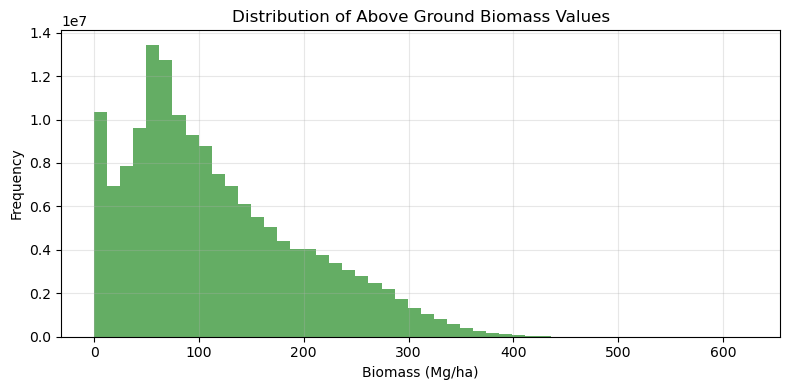

In [5]:
# Create a histogram of the biomass data
plt.figure(figsize=(8, 4))
plt.hist(band_valid.compressed(), bins=50, color='forestgreen', alpha=0.7)
plt.title('Distribution of Above Ground Biomass Values')
plt.xlabel('Biomass (Mg/ha)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
def from_wgs84(lat, lon):
    transformer_reverse = Transformer.from_crs(4326, 3035, always_xy=True)
    x, y = transformer_reverse.transform(lon, lat)
    return x, y

def to_wgs84(x, y):
    transformer = Transformer.from_crs(3035, 4326, always_xy=True)
    lon, lat = transformer.transform(x, y)
    return lon, lat

0.0 281.8352


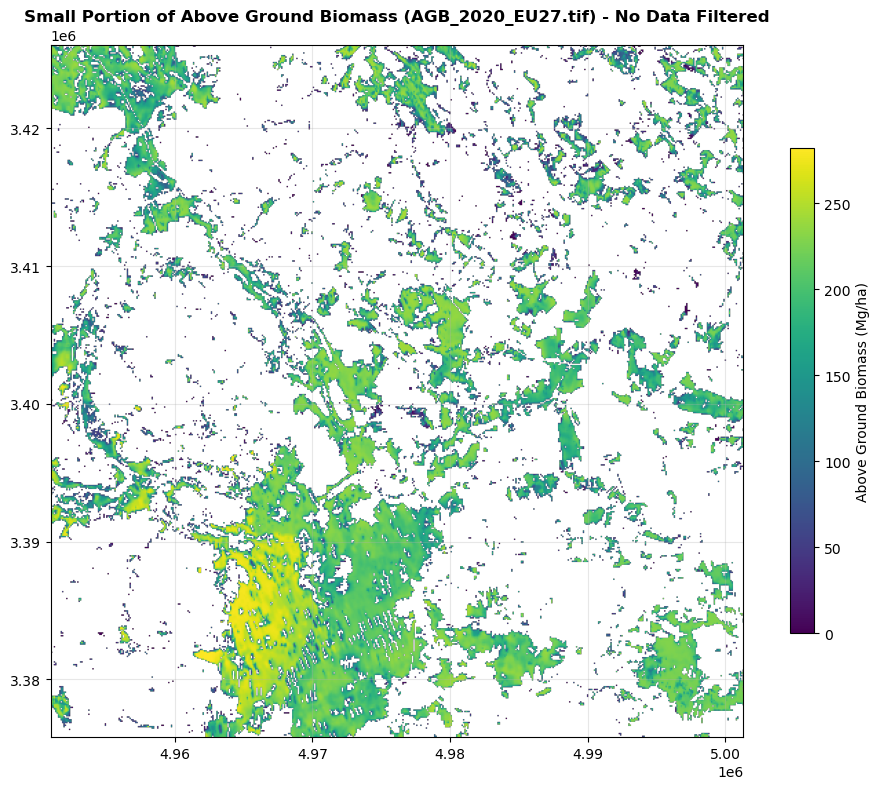

In [19]:
AGBM_PATH = 'data/biomass/AGB_2020_EU27.tif'
# Create a figure and axis for the visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Open the biomass data file
with rasterio.open(AGBM_PATH) as src:
    # Get the bounds of the data
    bounds = src.bounds
    
    # Define a window to read only a small portion of the data
    # Read a small window from the center of the image
    height, width = src.height, src.width
    window_size = min(height, width) // 80  # Use 1/4 of the smaller dimension
    
    # Calculate the window coordinates (centered)
    window_row_start = (height - window_size) // 2
    window_col_start = (width - window_size) // 2
    
    # Read the data for this window
    window = rasterio.windows.Window(window_col_start, window_row_start, window_size, window_size)
    data = src.read(1, window=window)
    
    # Filter out no data values (assuming 0 or negative values are no data)
    no_data_value = src.nodata if src.nodata is not None else 0
    valid_data = np.ma.masked_where(data <= no_data_value, data)
    
    print(valid_data.min(), valid_data.max())
    
    # Get the transform for this window
    window_transform = rasterio.windows.transform(window, src.transform)
    
    # Plot the small portion of biomass data with no data filtered out
    # Removed the norm parameter to ensure colorbar values are correct
    biomass_plot = show(
        valid_data, 
        ax=ax,
        transform=window_transform,
        cmap='viridis',
        title='Small Portion of Above Ground Biomass (AGB_2020_EU27.tif) - No Data Filtered'
    )
    
    # Add a colorbar
    cbar = plt.colorbar(biomass_plot.get_images()[0], ax=ax, shrink=0.7)
    cbar.set_label('Above Ground Biomass (Mg/ha)')

# Add grid lines
ax.grid(alpha=0.3)

# Improve layout
plt.tight_layout()
plt.show()


0.0 597.4203


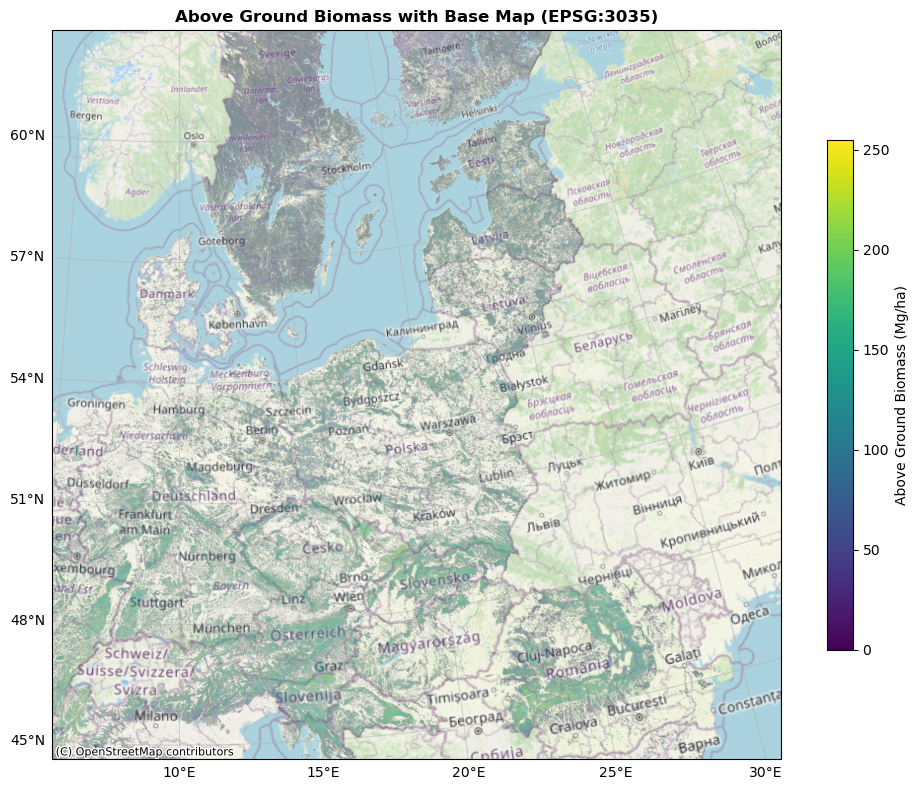

In [74]:
AGBM_PATH = 'data/biomass/AGB_2020_EU27.tif'
# Create a figure and axis for the visualization
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.epsg(3035))  # 正确方式：只用这个，不用 plt.subplots
# Open the biomass data file
with rasterio.open(AGBM_PATH) as src:
    # Get the bounds of the data
    bounds = src.bounds
    
    # Define a window to read only a small portion of the data
    # Read a small window from the center of the image
    height, width = src.height, src.width
    window_size = min(height, width) // 2 # Reduced from 1/4 to 1/8 of the smaller dimension
    
    # Calculate the window coordinates (centered)
    window_row_start = (height - window_size) // 2
    window_col_start = (width - window_size) // 2
    
    # Read the data for this window
    window = rasterio.windows.Window(window_col_start, window_row_start, window_size, window_size)
    data = src.read(1, window=window)
    
    # Apply downsampling to further reduce resolution
    downsampling_factor = 5
    data = data[::downsampling_factor, ::downsampling_factor]
    
    # Adjust the transform for the downsampled data
    window_transform = rasterio.windows.transform(window, src.transform)
    window_transform = rasterio.Affine(
        window_transform.a * downsampling_factor,
        window_transform.b,
        window_transform.c,
        window_transform.d,
        window_transform.e * downsampling_factor,
        window_transform.f
    )
    
    # Filter out no data values (using the nodata value from the source)
    no_data_value = src.nodata if src.nodata is not None else 0
    valid_data = np.ma.masked_where(data <= no_data_value, data)
    
    print(valid_data.min(), valid_data.max())
    
    # Get the window bounds in the original CRS (EPSG:3035)
    window_bounds = rasterio.windows.bounds(window, src.transform)
    
    # Create a contextily base map
    import contextily as ctx
    from pyproj import Transformer
    
    # First, create a function to transform from EPSG:3035 to Web Mercator (EPSG:3857)
    transformer = Transformer.from_crs("EPSG:3035", "EPSG:3857", always_xy=True)
    
    # Transform the window bounds to Web Mercator
    # Fix: window_bounds is a tuple (left, bottom, right, top), not an object with attributes
    left, bottom, right, top = window_bounds
    west, south = transformer.transform(left, bottom)
    east, north = transformer.transform(right, top)
    
    

# 设置可视范围
ax.set_extent([left, right, bottom, top], crs=ccrs.epsg(3035))

# 添加底图
ctx.add_basemap(ax, crs=ccrs.epsg(3035).to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# 叠加 biomass 图层
biomass_plot = show(
    valid_data,
    ax=ax,
    transform=window_transform,
    cmap='viridis',
    alpha=0.5,
    vmax=500,
    title='Above Ground Biomass with Base Map (EPSG:3035)'
)

# 添加 colorbar
cbar = plt.colorbar(biomass_plot.get_images()[0], ax=ax, shrink=0.7)
cbar.set_label('Above Ground Biomass (Mg/ha)')

# 添加地理坐标刻度
gl = ax.gridlines(draw_labels=True, alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

plt.tight_layout()
plt.show()


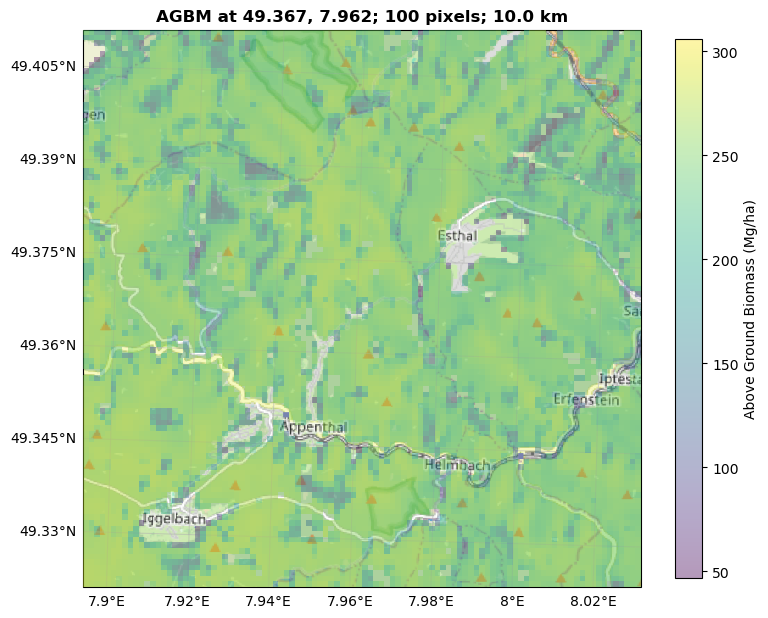

In [73]:
# Center coordinates (latitude, longitude)
center_lat, center_lon = 49.367, 7.962

# Convert center coordinates from WGS84 (EPSG:4326) to EPSG:3035
transformer_to_3035 = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
center_x, center_y = transformer_to_3035.transform(center_lon, center_lat)

# Define the window size (10x10 pixels)
window_size = 100

# Open the biomass raster
with rasterio.open(AGBM_PATH) as src:
    # Calculate pixel indices from coordinates
    row, col = src.index(center_x, center_y)
    
    # Define the window centered on the point (half window size on each side)
    half_size = window_size // 2
    window = Window(col - half_size, row - half_size, window_size, window_size)
    
    # Read the data and transform
    data = src.read(1, window=window)
    window_transform = src.window_transform(window)
    
    # Get the window bounds in EPSG:3035
    window_bounds = rasterio.windows.bounds(window, src.transform)
    
    # Filter out nodata values
    nodata = src.nodata
    valid_data = data.copy()
    if nodata is not None:
        valid_data = np.ma.masked_equal(data, nodata)
    
    # Create a new figure with a specific projection
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.epsg(3035)})
    
    # Set the extent of the map
    left, bottom, right, top = window_bounds
    ax.set_extent([left, right, bottom, top], crs=ccrs.epsg(3035))
    
    # Add base map using cartopy's cimgt instead of contextily
    from cartopy.io import img_tiles as cimgt
    
    # Create a tile source (OpenStreetMap)
    osm_tiles = cimgt.OSM()
    
    # Add the tiles to the map
    ax.add_image(osm_tiles, 12)  # Zoom level 14
    
    # Plot the biomass data with nodata filtered out
    show(
        valid_data,
        ax=ax,
        transform=window_transform,
        cmap='viridis',
        vmax=valid_data.max()+20,
        alpha=0.4,  # Add some transparency to see the base map
        title=f'AGBM at {center_lat}, {center_lon}; {window_size} pixels; {window_size/10} km',
        zorder=10
    )
    
    # Add a colorbar
    plt.colorbar(ax.get_images()[0], ax=ax, shrink=0.7, label='Above Ground Biomass (Mg/ha)')
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    plt.tight_layout()
    plt.show()